# Week 2 — EDA Deep Dive + Feature Engineering

**Goal**: Build and validate the full feature matrix used in Week 3 modelling.

**Outputs**:
- `data/processed/features_kaggle.csv` — TF-IDF + linguistic features, Kaggle data
- `data/processed/features_survey.csv` — same schema, survey data (add in Week 2 end)
- `data/processed/features_combined.csv` — merged final matrix
- EDA plots saved to `docs/`



## 0. Imports + config

In [16]:
import sys, os
sys.path.append('..') 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

from features import extract_features_batch, clean_texts_batch

# ── Plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 130,
    'font.family'     : 'DejaVu Sans',
    'axes.spines.top' : False,
    'axes.spines.right': False,
})
PALETTE = {'low': '#1D9E75', 'moderate': '#BA7517', 'high': '#D85A30'}
DOCS    = '../docs'
os.makedirs(DOCS, exist_ok=True)

LABEL_ORDER = ['low', 'high']
print('Setup complete.')

Setup complete.


## 1. Load + clean data

In [17]:
df = pd.read_csv('../data/processed/kaggle_combined_raw.csv')

print(f'Raw shape     : {df.shape}')
print(f'Columns       : {list(df.columns)}')
print(f'Label counts  :\n{df["label"].value_counts()}')
print(f'Null values   :\n{df.isnull().sum()}')

# Clean text
df['text_clean'] = clean_texts_batch(df['text'])

# Drop rows with empty text
before = len(df)
df = df[df['text_clean'].str.len() > 10].reset_index(drop=True)
print(f'\nDropped {before - len(df)} empty rows. Final shape: {df.shape}')

df.head(3)

Raw shape     : (35633, 3)
Columns       : ['text', 'label', 'source']
Label counts  :
label
low     17981
high    17652
Name: count, dtype: int64
Null values   :
text      0
label     0
source    0
dtype: int64

Dropped 2 empty rows. Final shape: (35631, 4)


,text,label,source,text_clean
0,we understand that most people who reply immed...,high,depression_reddit,we understand that most people who reply immed...
1,welcome to r depression s check in post a plac...,high,depression_reddit,welcome to r depression s check in post a plac...
2,anyone else instead of sleeping more when depr...,high,depression_reddit,anyone else instead of sleeping more when depr...


## 2. Class distribution

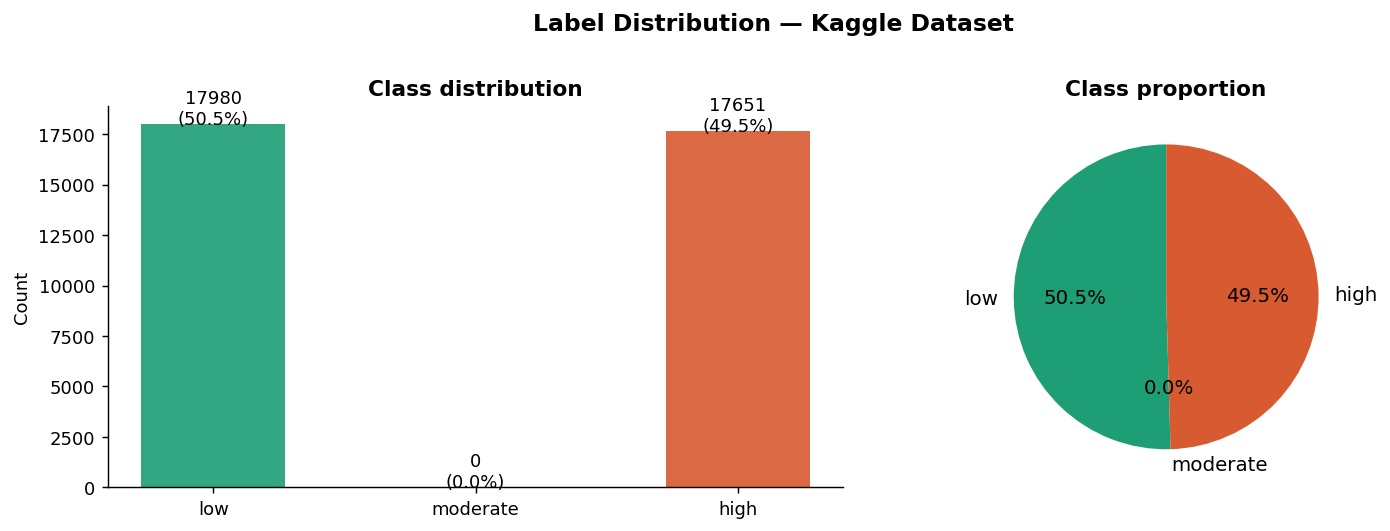

Imbalance ratio (max/min): infx


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['label'].value_counts().reindex(LABEL_ORDER).fillna(0)
colors = [PALETTE[l] for l in LABEL_ORDER]
bars = axes[0].bar(LABEL_ORDER, counts.values, color=colors, alpha=0.9, width=0.55)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{int(val)}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Class distribution', fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(counts.values, labels=LABEL_ORDER, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Class proportion', fontweight='bold')

plt.suptitle('Label Distribution — Kaggle Dataset', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{DOCS}/plot_01_class_distribution.png', bbox_inches='tight')
plt.show()

imbalance_ratio = counts.max() / counts.min()
print(f'Imbalance ratio (max/min): {imbalance_ratio:.2f}x')


## 3. Text length analysis by class

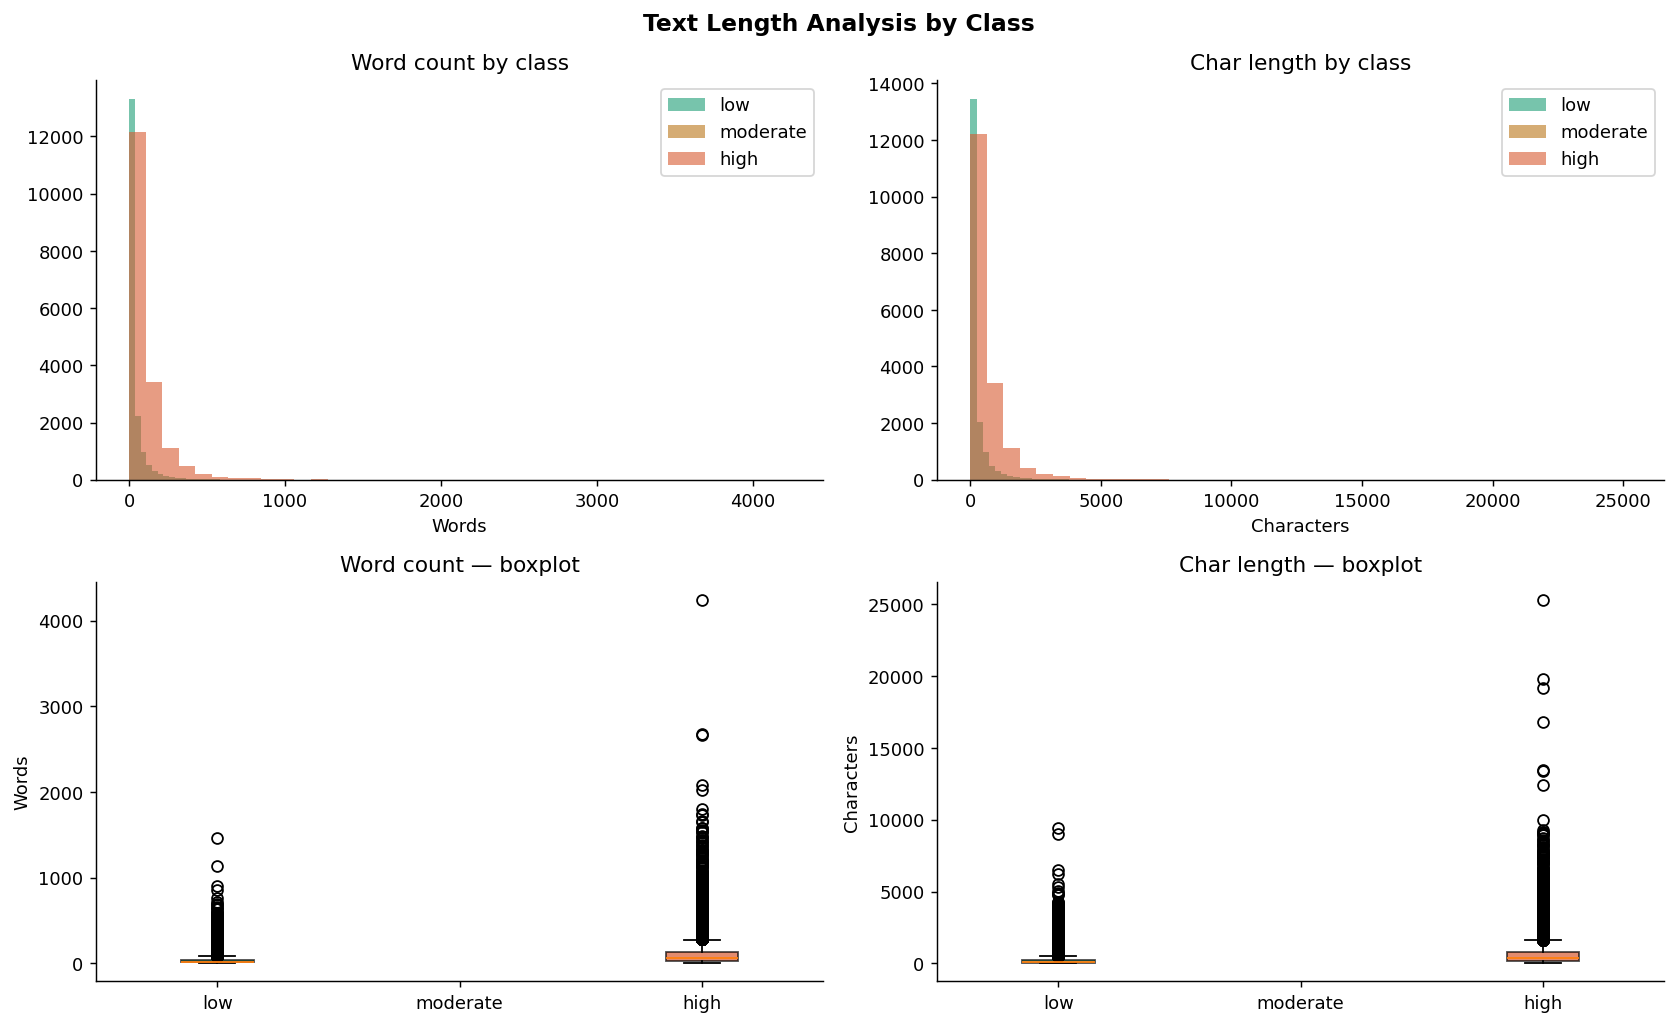

      word_count                                               char_len  \
           count   mean    std  min   25%   50%    75%     max    count   
label                                                                     
high     17651.0  105.3  140.8  1.0  30.0  62.0  129.0  4239.0  17651.0   
low      17980.0   40.4   64.5  1.0  11.0  18.0   40.0  1462.0  17980.0   

                                                         
        mean    std   min    25%    50%    75%      max  
label                                                    
high   625.1  844.8  11.0  179.5  375.0  765.0  25289.0  
low    259.7  444.4  11.0   60.0  105.0  251.0   9401.0  


In [19]:
df['word_count'] = df['text_clean'].str.split().str.len()
df['char_len']   = df['text_clean'].str.len()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for label in LABEL_ORDER:
    subset = df[df['label'] == label]
    axes[0,0].hist(subset['word_count'], bins=40, alpha=0.6, label=label, color=PALETTE[label])
    axes[0,1].hist(subset['char_len'],   bins=40, alpha=0.6, label=label, color=PALETTE[label])

axes[0,0].set_title('Word count by class'); axes[0,0].set_xlabel('Words'); axes[0,0].legend()
axes[0,1].set_title('Char length by class'); axes[0,1].set_xlabel('Characters'); axes[0,1].legend()

# Box plots
data_wc = [df[df['label']==l]['word_count'].values for l in LABEL_ORDER]
data_cl = [df[df['label']==l]['char_len'].values   for l in LABEL_ORDER]
bp1 = axes[1,0].boxplot(data_wc, labels=LABEL_ORDER, patch_artist=True)
bp2 = axes[1,1].boxplot(data_cl, labels=LABEL_ORDER, patch_artist=True)
for bp, ax in [(bp1, axes[1,0]), (bp2, axes[1,1])]:
    for patch, lbl in zip(bp['boxes'], LABEL_ORDER):
        patch.set_facecolor(PALETTE[lbl]); patch.set_alpha(0.7)
axes[1,0].set_title('Word count — boxplot'); axes[1,0].set_ylabel('Words')
axes[1,1].set_title('Char length — boxplot'); axes[1,1].set_ylabel('Characters')

plt.suptitle('Text Length Analysis by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DOCS}/plot_02_text_length.png', bbox_inches='tight')
plt.show()

print(df.groupby('label')[['word_count','char_len']].describe().round(1))



## 4. Top TF-IDF tokens per class

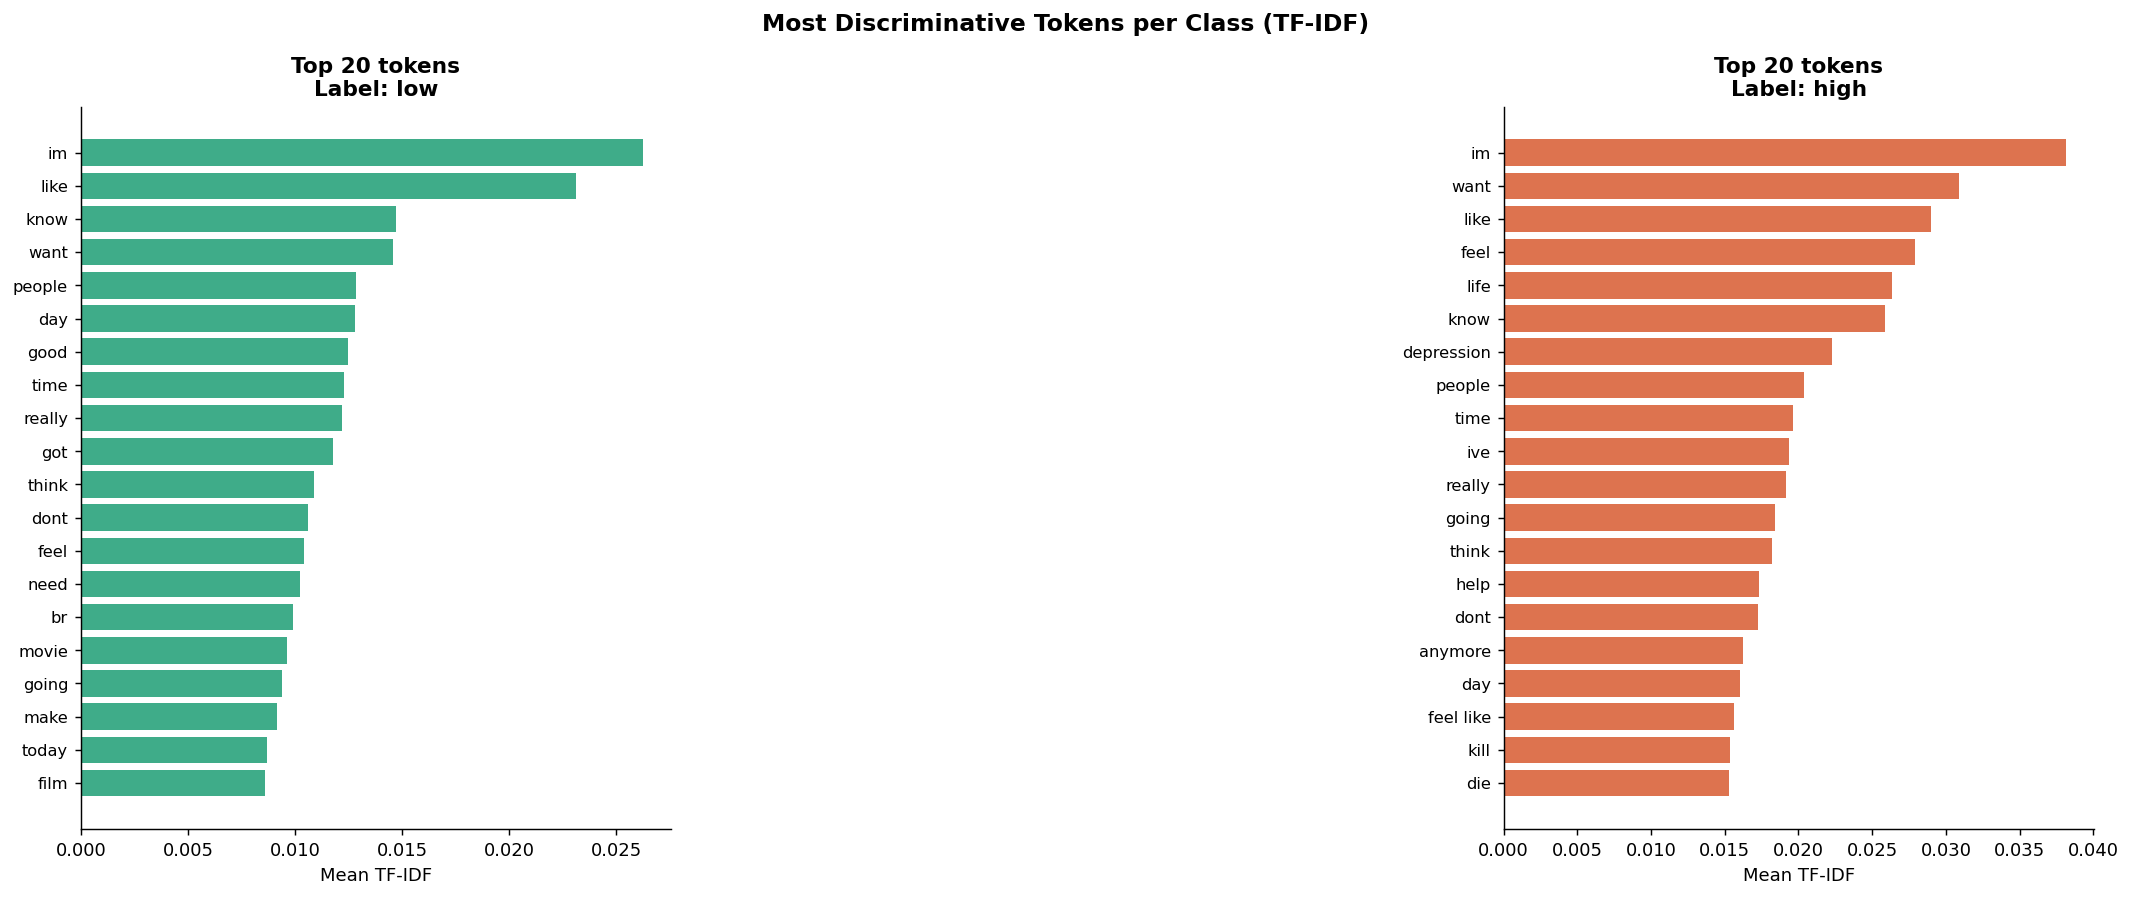

In [20]:
TOP_N = 20
fig, axes = plt.subplots(1, len(LABEL_ORDER), figsize=(5.5 * len(LABEL_ORDER), 7))

for ax, label in zip(axes, LABEL_ORDER):
    subset = df[df['label'] == label]['text_clean'].fillna('')

    # Skip classes with no samples
    if subset.empty:
        ax.set_visible(False)
        continue

    vec = TfidfVectorizer(
        max_features=8000,
        stop_words='english',
        ngram_range=(1, 2),
        sublinear_tf=True
    )

    tfidf_matrix = vec.fit_transform(subset)
    scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
    top_idx = scores.argsort()[-TOP_N:][::-1]
    top_tokens = [vec.get_feature_names_out()[i] for i in top_idx]
    top_scores = scores[top_idx]

    ax.barh(top_tokens[::-1], top_scores[::-1], color=PALETTE[label], alpha=0.85)
    ax.set_title(f'Top {TOP_N} tokens\nLabel: {label}', fontweight='bold')
    ax.set_xlabel('Mean TF-IDF')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Most Discriminative Tokens per Class (TF-IDF)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DOCS}/plot_03_tfidf_tokens.png', bbox_inches='tight')
plt.show()

## 5. Linguistic feature extraction

In [21]:
print('Extracting 24 linguistic features...')
feat_df = extract_features_batch(df['text_clean'])
feat_df['label'] = df['label'].values

print(f'Feature matrix shape: {feat_df.shape}')
print(f'Features: {[c for c in feat_df.columns if c != "label"]}')
feat_df.describe().round(3)

Extracting 24 linguistic features...
Feature matrix shape: (35631, 25)
Features: ['char_len', 'word_count', 'avg_word_len', 'sentence_count', 'avg_sent_len', 'negation_count', 'negation_rate', 'fp_singular_count', 'fp_singular_rate', 'fp_plural_count', 'fp_plural_rate', 'positive_affect', 'negative_affect', 'affect_balance', 'affect_ratio', 'future_tense_count', 'past_tense_count', 'temporal_balance', 'type_token_ratio', 'question_count', 'exclamation_count', 'ellipsis_count', 'punctuation_count', 'punctuation_density']


,char_len,word_count,avg_word_len,sentence_count,avg_sent_len,negation_count,negation_rate,fp_singular_count,fp_singular_rate,fp_plural_count,...,affect_ratio,future_tense_count,past_tense_count,temporal_balance,type_token_ratio,question_count,exclamation_count,ellipsis_count,punctuation_count,punctuation_density
count,35631.000,35631.000,35631.000,35631.0,35631.000,35631.000,35631.000,35631.000,35631.000,35631.000,...,35631.000,35631.000,35631.000,35631.000,35631.000,35631.0,35631.0,35631.0,35631.000,35631.000
mean,440.691,72.538,5.387,1.0,72.538,0.735,0.009,2.241,0.024,0.112,...,0.304,0.800,3.268,-2.467,0.855,0.0,0.0,0.0,0.058,0.001
std,697.525,113.900,36.569,0.0,113.900,1.741,0.023,8.503,0.046,0.690,...,0.998,1.807,6.612,5.676,0.132,0.0,0.0,0.0,0.889,0.006
min,11.000,1.000,1.100,1.0,1.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,-200.000,0.004,0.0,0.0,0.0,0.000,0.000
25%,84.000,15.000,4.579,1.0,15.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,-3.000,0.787,0.0,0.0,0.0,0.000,0.000
50%,203.000,33.000,5.149,1.0,33.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,1.000,-1.000,0.875,0.0,0.0,0.0,0.000,0.000
75%,527.000,86.000,5.559,1.0,86.000,1.000,0.010,1.000,0.022,0.000,...,0.000,1.000,4.000,0.000,0.957,0.0,0.0,0.0,0.000,0.000
max,25289.000,4239.000,6321.500,1.0,4239.000,81.000,0.667,526.000,0.875,34.000,...,121.000,50.000,222.000,41.000,1.000,0.0,0.0,0.0,96.000,0.200


## 6. Feature distributions by class

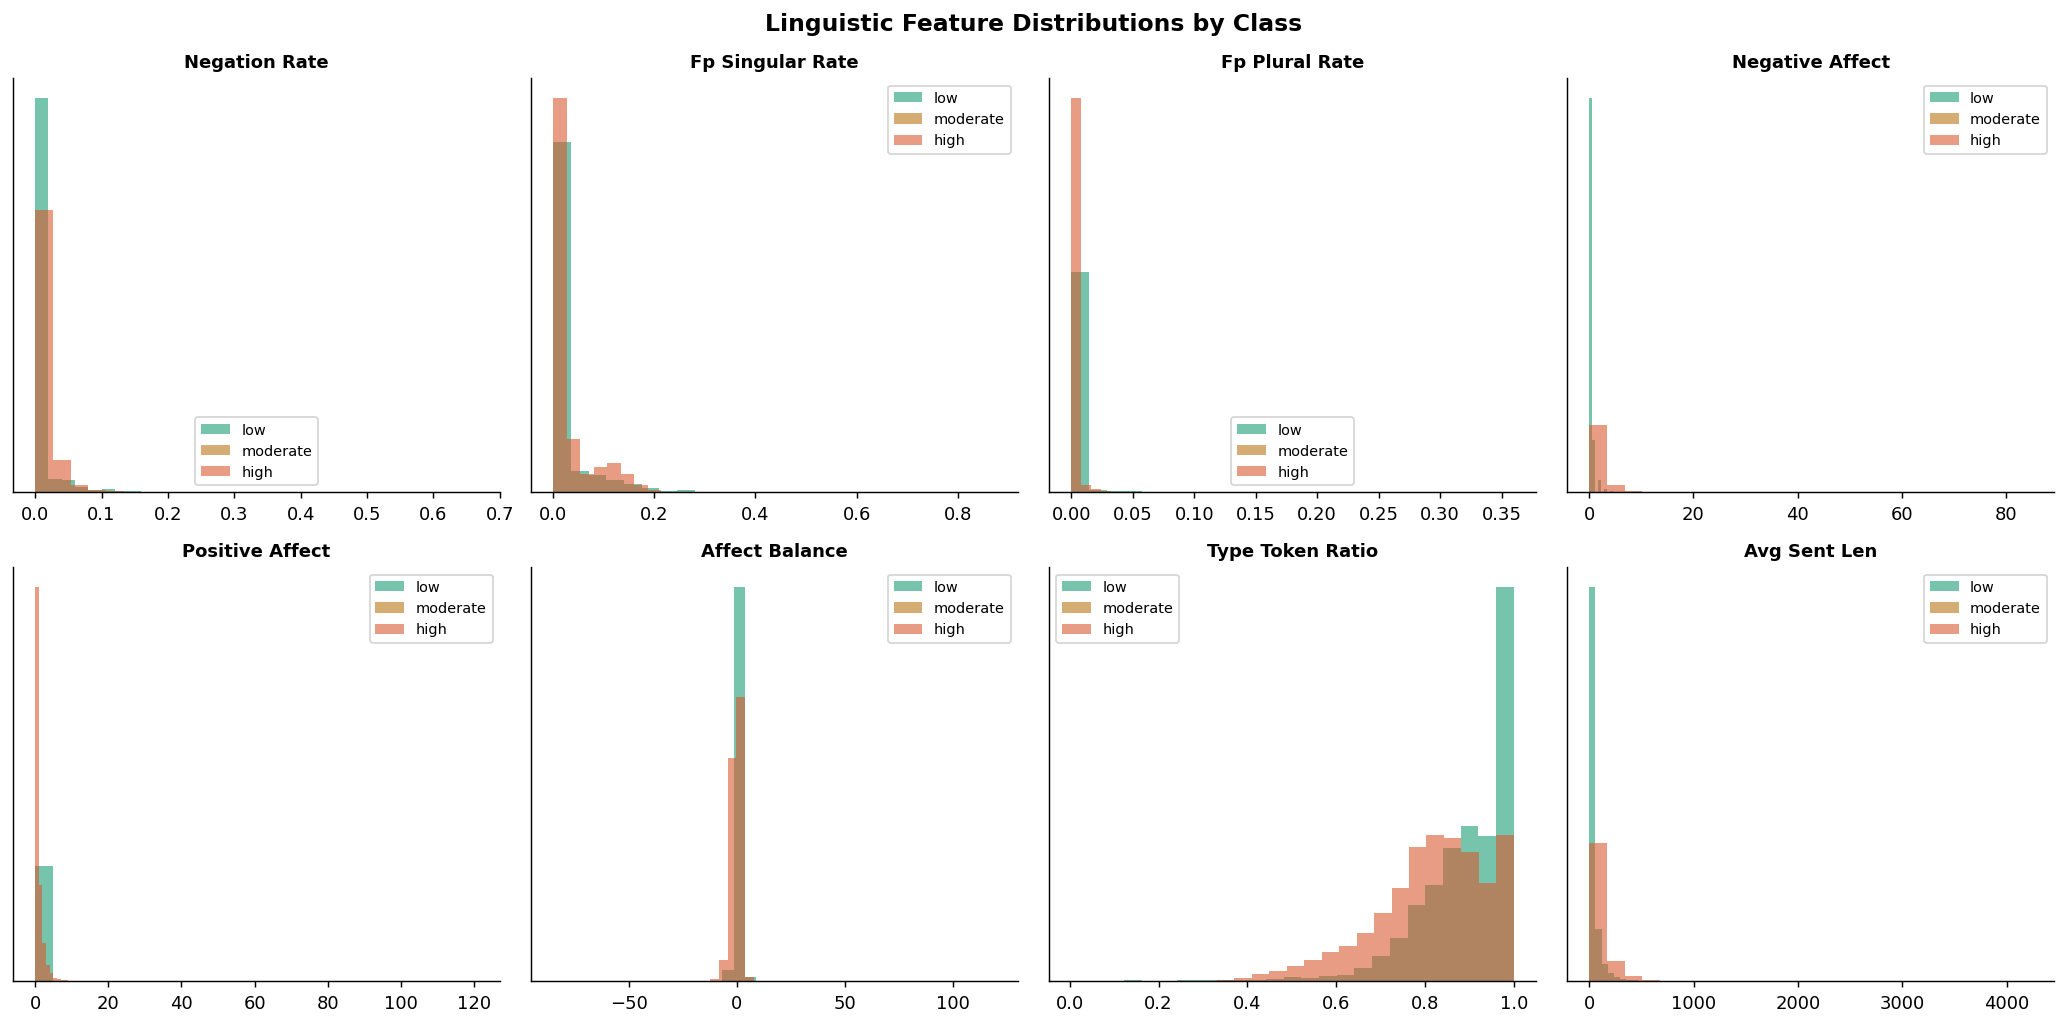

In [22]:
# Plotting the 8 most interesting features side by side
KEY_FEATURES = [
    'negation_rate', 'fp_singular_rate', 'fp_plural_rate',
    'negative_affect', 'positive_affect', 'affect_balance',
    'type_token_ratio', 'avg_sent_len'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, feat in zip(axes, KEY_FEATURES):
    for label in LABEL_ORDER:
        vals = feat_df[feat_df['label'] == label][feat].dropna()
        ax.hist(vals, bins=25, alpha=0.6, label=label, color=PALETTE[label], density=True)
    ax.set_title(feat.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_yticks([])

plt.suptitle('Linguistic Feature Distributions by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DOCS}/plot_04_feature_distributions.png', bbox_inches='tight')
plt.show()


## 7. Feature–label correlation heatmap

Label encoding: {'high': 0, 'low': 1}


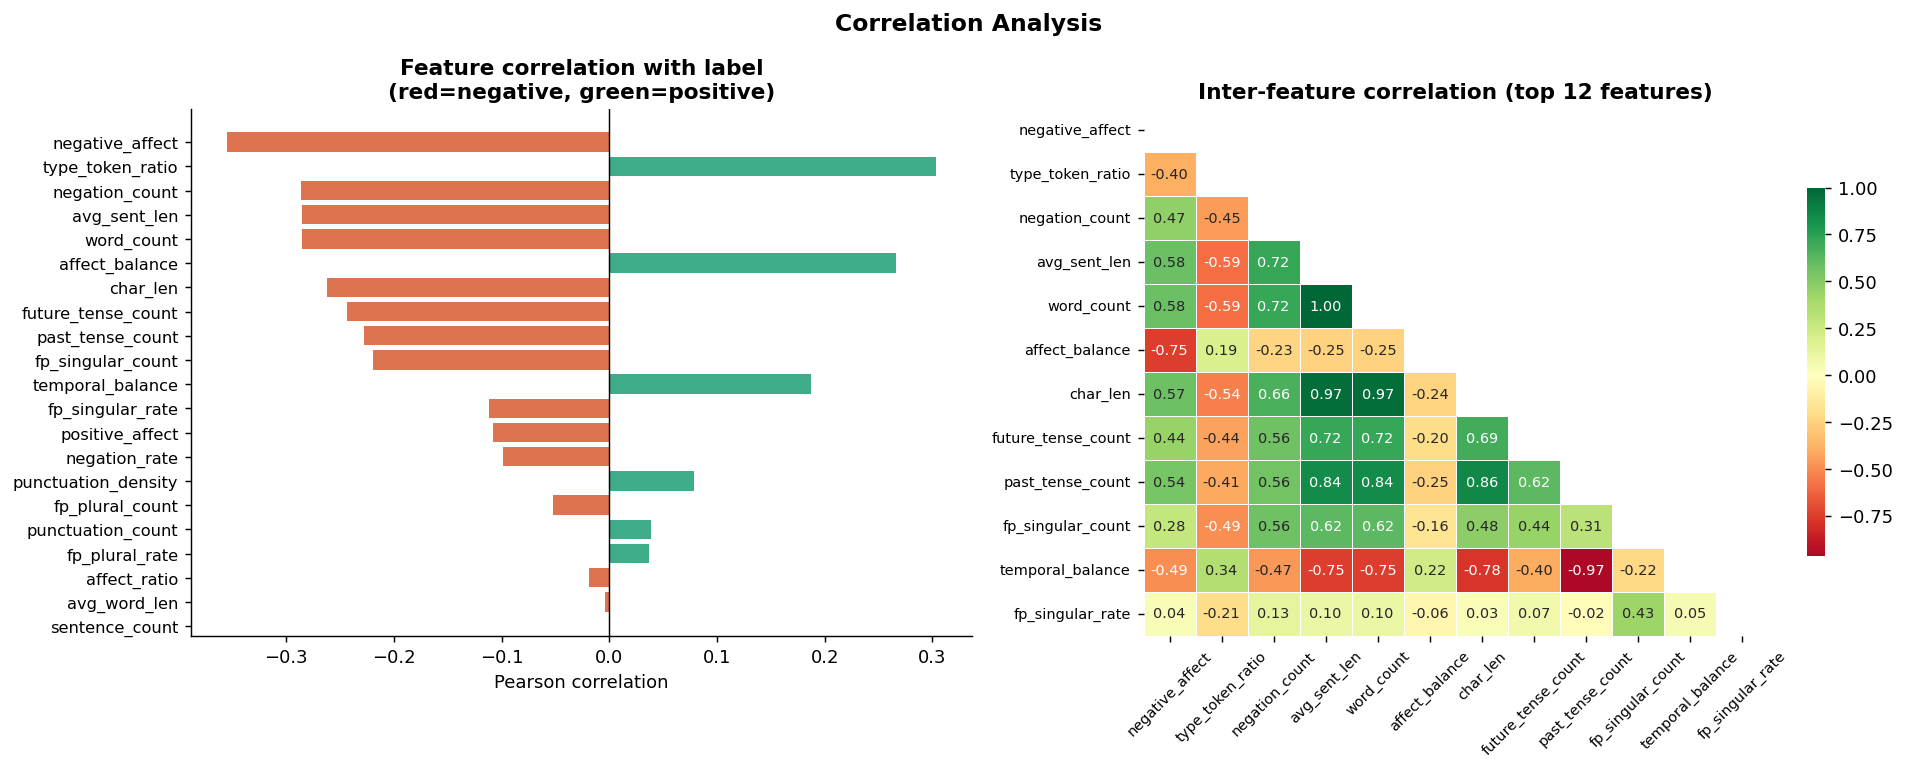


Top 5 features by absolute correlation with label:
negative_affect    -0.3553
type_token_ratio    0.3034
negation_count     -0.2860
avg_sent_len       -0.2851
word_count         -0.2851
Name: label_enc, dtype: float64


In [23]:
le = LabelEncoder()
feat_df['label_enc'] = le.fit_transform(feat_df['label'])
print(f'Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Correlation with label
numeric_cols = [c for c in feat_df.columns if c not in ['label', 'label_enc']]
corr_with_label = (
    feat_df[numeric_cols + ['label_enc']]
    .corr()['label_enc']
    .drop('label_enc')
    .sort_values(key=abs, ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar: correlation with label
bar_colors = ['#D85A30' if v < 0 else '#1D9E75' for v in corr_with_label.values]
axes[0].barh(corr_with_label.index[::-1], corr_with_label.values[::-1], color=bar_colors[::-1], alpha=0.85)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Feature correlation with label\n(red=negative, green=positive)', fontweight='bold')
axes[0].set_xlabel('Pearson correlation')
axes[0].tick_params(axis='y', labelsize=9)

# Heatmap: inter-feature correlation (top 12 features)
top12 = corr_with_label.head(12).index.tolist()
corr_matrix = feat_df[top12].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=axes[1], cmap='RdYlGn',
            center=0, annot=True, fmt='.2f', annot_kws={'size': 8},
            linewidths=0.5, cbar_kws={'shrink': 0.7})
axes[1].set_title('Inter-feature correlation (top 12 features)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle('Correlation Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DOCS}/plot_05_correlation.png', bbox_inches='tight')
plt.show()

print('\nTop 5 features by absolute correlation with label:')
print(corr_with_label.head(5).round(4))


## 8. TF-IDF matrix (full pipeline)

In [24]:
TFIDF_PARAMS = dict(
    max_features  = 10_000,
    ngram_range   = (1, 2),
    stop_words    = 'english',
    sublinear_tf  = True,   
    min_df        = 3,      
    max_df        = 0.90,   
)

vectorizer = TfidfVectorizer(**TFIDF_PARAMS)
X_tfidf    = vectorizer.fit_transform(df['text_clean'])

print(f'TF-IDF matrix shape : {X_tfidf.shape}')
print(f'Vocabulary size     : {len(vectorizer.vocabulary_)}')
print(f'Sparsity            : {1 - X_tfidf.nnz / (X_tfidf.shape[0]*X_tfidf.shape[1]):.4f}')

# Showing top 10 tokens overall
scores_overall = np.asarray(X_tfidf.mean(axis=0)).flatten()
top10_idx      = scores_overall.argsort()[-10:][::-1]
top10_tokens   = [vectorizer.get_feature_names_out()[i] for i in top10_idx]
print(f'\nTop 10 tokens overall: {top10_tokens}')



TF-IDF matrix shape : (35631, 10000)
Vocabulary size     : 10000
Sparsity            : 0.9957

Top 10 tokens overall: ['im', 'like', 'want', 'know', 'feel', 'life', 'people', 'time', 'really', 'think']


## 9. Class imbalance handling — SMOTE experiment

=== Class imbalance strategies comparison ===
Original   : {'high': 17651, 'low': 17980}
After SMOTE: {'high': 17980, 'low': 17980}


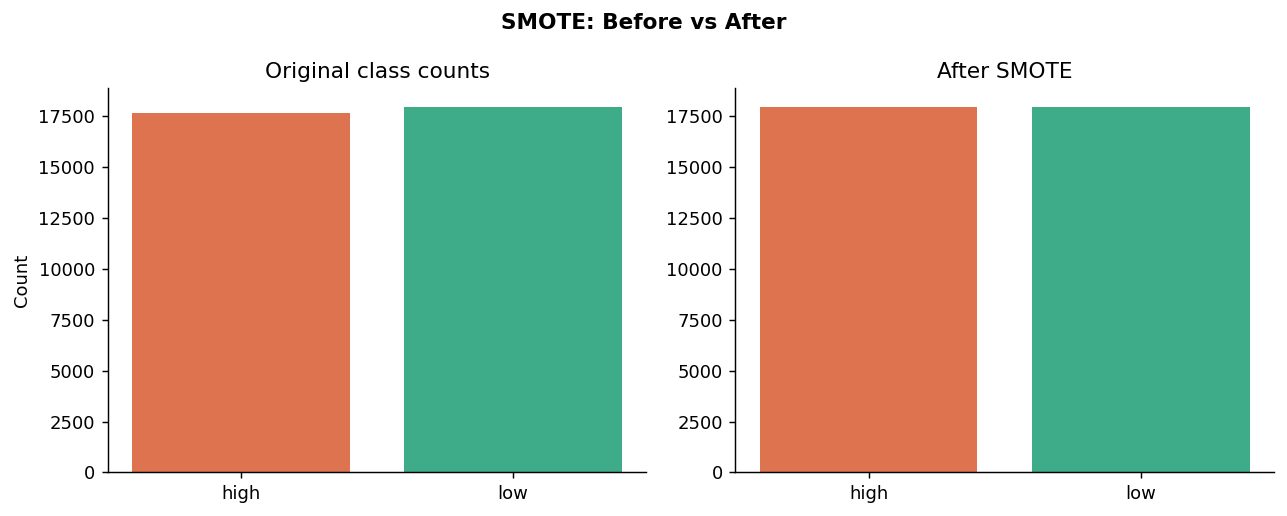

In [25]:
y = le.transform(df['label'])

print('=== Class imbalance strategies comparison ===')
print(f'Original   : {dict(zip(le.classes_, np.bincount(y)))}')

# Strategy 1: SMOTE on TF-IDF
sm = SMOTE(random_state=42)
X_sm, y_sm = sm.fit_resample(X_tfidf, y)
print(f'After SMOTE: {dict(zip(le.classes_, np.bincount(y_sm)))}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
counts_orig = np.bincount(y)
counts_sm   = np.bincount(y_sm)

x = np.arange(len(le.classes_))
axes[0].bar(x, counts_orig, color=[PALETTE[l] for l in le.classes_], alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(le.classes_)
axes[0].set_title('Original class counts'); axes[0].set_ylabel('Count')

axes[1].bar(x, counts_sm, color=[PALETTE[l] for l in le.classes_], alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(le.classes_)
axes[1].set_title('After SMOTE')

plt.suptitle('SMOTE: Before vs After', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DOCS}/plot_06_smote.png', bbox_inches='tight')
plt.show()



## 10. Save final feature matrix

In [26]:
import scipy.sparse as sp

# Save linguistic feature matrix (dense CSV)
save_df = feat_df.copy()
save_df['text_clean'] = df['text_clean'].values
save_df['source']     = df['source'].values
save_df.to_csv('../data/processed/features_kaggle.csv', index=False)
print(f'Saved: data/processed/features_kaggle.csv  {save_df.shape}')

# Save TF-IDF matrix (sparse format — efficient)
sp.save_npz('../data/processed/tfidf_kaggle.npz', X_tfidf)
import joblib
joblib.dump(vectorizer, '../models/tfidf_vectorizer.pkl')
joblib.dump(le,         '../models/label_encoder.pkl')
print('Saved: data/processed/tfidf_kaggle.npz')
print('Saved: models/tfidf_vectorizer.pkl')
print('Saved: models/label_encoder.pkl')

Saved: data/processed/features_kaggle.csv  (35631, 28)
Saved: data/processed/tfidf_kaggle.npz
Saved: models/tfidf_vectorizer.pkl
Saved: models/label_encoder.pkl


## 11. Merge survey data

In [27]:
survey_path = '../data/processed/survey_clean.csv'

if not os.path.exists(survey_path):
    print('[SKIP] Survey data not yet available. Run process_survey.py first.')
else:
    survey = pd.read_csv(survey_path)
    print(f'Survey data loaded: {survey.shape}')
    print(f'Columns: {list(survey.columns)}')

    # The survey has text_combined + label columns from process_survey.py
    # To extract same linguistic features
    survey_feats = extract_features_batch(survey['text_combined'])
    survey_feats['label']      = survey['label'].values
    survey_feats['text_clean'] = clean_texts_batch(survey['text_combined']).values
    survey_feats['source']     = 'survey'

    # Adding lifestyle features (if available)
    lifestyle_cols = [
        'sleep_enc', 'social_outings_enc', 'screen_time_enc',
        'caffeine_enc', 'exercise_enc', 'meals_enc', 'pss_score'
    ]
    for col in lifestyle_cols:
        if col in survey.columns:
            survey_feats[col] = survey[col].values

    survey_feats.to_csv('../data/processed/features_survey.csv', index=False)
    print(f'Saved: data/processed/features_survey.csv  {survey_feats.shape}')

    # Merge Kaggle + survey
    kaggle_feats = pd.read_csv('../data/processed/features_kaggle.csv')
    combined = pd.concat([kaggle_feats, survey_feats], ignore_index=True, sort=False)
    combined.fillna(0, inplace=True)
    combined.to_csv('../data/processed/features_combined.csv', index=False)
    print(f'\nCombined feature matrix: {combined.shape}')
    print(f'Label distribution:\n{combined["label"].value_counts()}')

[SKIP] Survey data not yet available. Run process_survey.py first.
